### `---------------Mandatory Information to fill------------`

### Group ID: 21
### Group Members Name with Student ID:
1. Saraswathi S , 2024AD05063
2. Student 2
3. Student 3
4. Student 4


`-------------------Write your remarks (if any) that you want should get consider at the time of evaluation---------------`

Remarks: ##Add here

# Background

A large e-commerce organization operates a homepage recommendation slot that displays one product to each visiting user. The company aims to maximize long-term net profit from these recommendations.

You are provided with a dataset of **498 user sessions**, each representing how a particular user would respond to each of six products.

Link for accessing dataset:
https://drive.google.com/file/d/14yDuW-zFs9-fh6ySH9xmULFcZuKVhn1r/view?usp=sharing


The dataset structure is:

*UserID, Product1, cost1, Product2, cost2, … , Product6, cost6*


Each row corresponds to one user and contains the following information.

## Product X column
The value under **Product X** represents the actual revenue the system would earn from that specific user if Product X were shown.

Revenue varies across users because:

- different users purchase different quantities  
- some users click while others ignore  
- some users spend more  
- some users purchase premium items or bundles  

Thus, actual revenue is **user-dependent**, not product-dependent.  
The same product may generate high revenue from one user and very low revenue from another.

## Cost X column
The value under **cost X** represents the personalized promotional cost incurred to show Product X to that user. This may include:

- dynamic advertisement bidding cost (CPC)  
- discounts or coupon values offered  
- targeted promotion cost  
- personalization overhead  

Costs differ across users because:

- some users require higher incentive levels  
- some are expensive to target via ads  
- some convert easily with minimal cost  

Thus, cost is also **user-dependent** and varies per session.



# Environment Dynamics

## Arms
In the Multi-Armed Bandit formulation:

There are **6 arms**:
A = {1, 2, 3, 4, 5, 6}

Arm X corresponds to recommending **Product X**.

## Reward
For each product X and each user session i:

$
\text{NetReward}_{i,X} = \text{Product}_{i,X} - \text{Cost}_{i,X}
$

This net reward represents the **profit** gained from showing product X to user i.  
This is the metric the organization aims to maximize.


# Current Organizational Policy

The organization currently follows a **random recommendation policy**:

“For each user visit, randomly select one of the six products and display it.”

This strategy:

- does not learn from previous outcomes  
- does not identify which products consistently deliver higher profit  
- wastes impressions on low-value products  
- provides unstable and suboptimal profit performance  

Management asks you to investigate:

- Whether a learning-based approach can yield better decisions  
- Which products are actually profitable when user variability is considered  
- How alternative strategies compare to the random policy  



# Requirements and Deliverables:
Implement the Multi-Arm Bandit Problem for the given above scenario.

### Initialize constants

In [1]:
# Initialize Constants
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


# Design a Product Environment with Reward calculation (1M)

In [2]:
# Code for Dataset loading and print dataset statistics along with reward function

# Identify one product that frequently gives high positive profit.
# Identify one product that frequently gives low or negative profit across the user sessions.
#-----write your code below this line---------

class ProductEnvironment:
    """Environment for Multi-Armed Bandit Product Recommendation Problem"""
    
    def __init__(self, dataset_path):
        """Initialize the environment by loading the dataset"""
        self.df = pd.read_csv(dataset_path)
        self.num_users = len(self.df)
        self.num_products = 6
        
        # Compute net rewards for each product
        for i in range(1, self.num_products + 1):
            product_col = f'Product {i}'
            cost_col = f'cost {i}'
            self.df[f'NetReward{i}'] = self.df[product_col] - self.df[cost_col]
        
        # Compute summary statistics
        self.compute_summary_stats()
    
    def compute_summary_stats(self):
        """Compute summary statistics for each product"""
        print("="*80)
        print("NET REWARD ANALYSIS")
        print("="*80)
        
        summary_data = []
        for i in range(1, self.num_products + 1):
            mean_reward = self.df[f'NetReward{i}'].mean()
            median_reward = self.df[f'NetReward{i}'].median()
            std_reward = self.df[f'NetReward{i}'].std()
            positive_count = (self.df[f'NetReward{i}'] > 0).sum()
            negative_count = (self.df[f'NetReward{i}'] < 0).sum()
            
            summary_data.append({
                'Product': i,
                'Mean': mean_reward,
                'Median': median_reward,
                'Std Dev': std_reward,
                'Positive': positive_count,
                'Negative': negative_count
            })
        
        self.summary_df = pd.DataFrame(summary_data)
        print("\nNet Reward Summary Statistics:\n")
        print(self.summary_df.to_string(index=False))
        
        # Identify best and worst products
        self.best_product = int(self.summary_df.loc[self.summary_df['Mean'].idxmax(), 'Product'])
        self.worst_product = int(self.summary_df.loc[self.summary_df['Mean'].idxmin(), 'Product'])
        self.best_mean = self.summary_df.loc[self.summary_df['Mean'].idxmax(), 'Mean']
        self.worst_mean = self.summary_df.loc[self.summary_df['Mean'].idxmin(), 'Mean']
        
        print(f"\n{'─'*80}")
        print(f"\n✓ FINDING 1: Best Product (High Positive Profit)")
        print(f"  Product {self.best_product} with average net reward = ${self.best_mean:.2f}")
        print(f"\n✓ FINDING 2: Worst Product (Low/Negative Profit)")
        print(f"  Product {self.worst_product} with average net reward = ${self.worst_mean:.2f}")
        print(f"\n{'─'*80}\n")
    
    def get_reward(self, user_idx, product):
        """Get the reward for a specific user and product"""
        return self.df.loc[user_idx, f'NetReward{product}']
    
    def get_random_user(self, round_num):
        """Get a random user index for a given round (cyclic through users)"""
        return round_num % self.num_users

# Load the environment
dataset_path = '/Users/saraswathi/Projects/Projects/DRLBasics/Dataset_Product_Recommendation.csv'
env = ProductEnvironment(dataset_path)

NET REWARD ANALYSIS

Net Reward Summary Statistics:

 Product       Mean     Median  Std Dev  Positive  Negative
       1   7.062784   7.103686 0.959895       498         0
       2  66.992995  67.009643 0.754517       498         0
       3  31.418452  31.487591 1.687144       498         0
       4   9.596789   9.622267 1.247947       498         0
       5 -17.064884 -17.061668 0.609228         0       498
       6  36.986031  37.044041 1.079589       498         0

────────────────────────────────────────────────────────────────────────────────

✓ FINDING 1: Best Product (High Positive Profit)
  Product 2 with average net reward = $66.99

✓ FINDING 2: Worst Product (Low/Negative Profit)
  Product 5 with average net reward = $-17.06

────────────────────────────────────────────────────────────────────────────────



#Implement the existing Strategy 1 (1M)




STRATEGY 1: RANDOM POLICY SIMULATION

Simulation Setup:
  • Number of rounds: 300
  • Number of users: 498
  • Number of products: 6

────────────────────────────────────────────────────────────────────────────────

Random Policy Results (300 rounds):

  Average profit per round: $21.65
  Cumulative profit: $6494.45
  Min reward: $-17.77
  Max reward: $68.63

Product Selection Frequency (Random Policy):
  Product 1: 57 times (avg reward: $7.08)
  Product 2: 42 times (avg reward: $67.12)
  Product 3: 52 times (avg reward: $31.23)
  Product 4: 64 times (avg reward: $9.54)
  Product 5: 39 times (avg reward: $-17.02)
  Product 6: 46 times (avg reward: $36.99)

────────────────────────────────────────────────────────────────────────────────



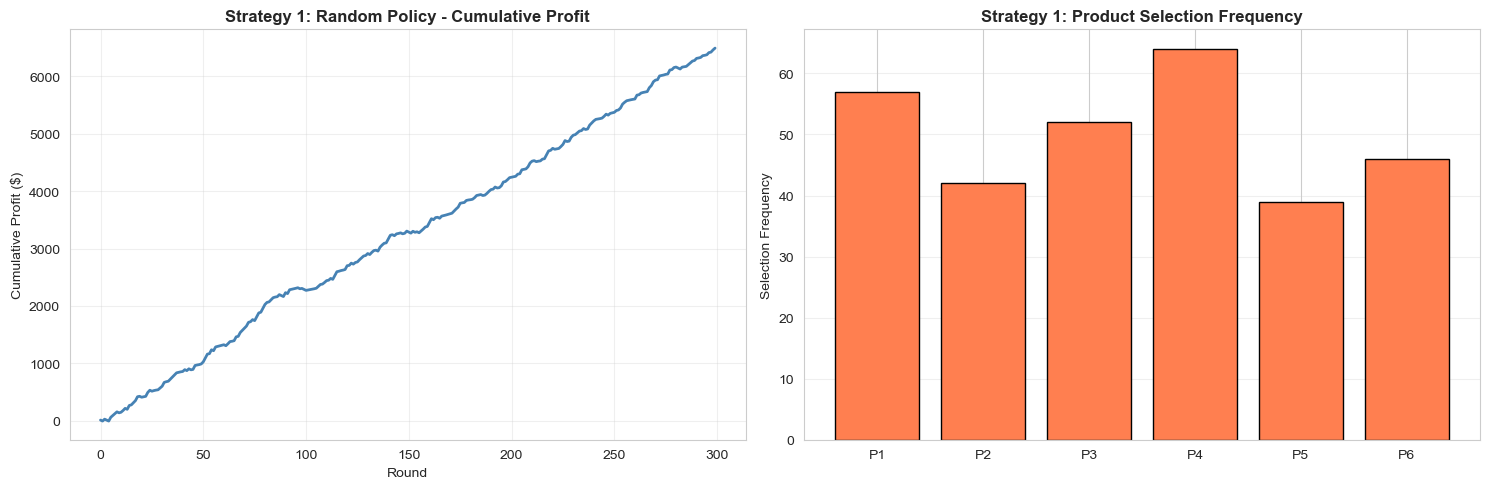

In [3]:
# Which product appears good and which appears poor under the existing process?
# What is the approximate average profit per round under this strategy?
# Did randomness occasionally pick a good product?

#-----write your code below this line---------

# Random Policy Simulation
print("\n" + "="*80)
print("STRATEGY 1: RANDOM POLICY SIMULATION")
print("="*80)

num_rounds = 300

# Track random policy performance
random_rewards = []
random_products = []

print(f"\nSimulation Setup:")
print(f"  • Number of rounds: {num_rounds}")
print(f"  • Number of users: {env.num_users}")
print(f"  • Number of products: {env.num_products}")

# Simulate random policy
for round_idx in range(num_rounds):
    user_idx = env.get_random_user(round_idx)
    selected_product = np.random.randint(1, 7)
    reward = env.get_reward(user_idx, selected_product)
    random_rewards.append(reward)
    random_products.append(selected_product)

# Calculate statistics
avg_reward_random = np.mean(random_rewards)
cumulative_random = np.cumsum(random_rewards)
product_counts_random = pd.Series(random_products).value_counts().sort_index()

print(f"\n{'─'*80}")
print(f"\nRandom Policy Results (300 rounds):\n")
print(f"  Average profit per round: ${avg_reward_random:.2f}")
print(f"  Cumulative profit: ${cumulative_random[-1]:.2f}")
print(f"  Min reward: ${np.min(random_rewards):.2f}")
print(f"  Max reward: ${np.max(random_rewards):.2f}")

print(f"\nProduct Selection Frequency (Random Policy):")
for product in range(1, 7):
    count = product_counts_random.get(product, 0)
    if count > 0:
        avg_prod = np.mean([random_rewards[i] for i in range(len(random_products)) if random_products[i] == product])
        print(f"  Product {product}: {count} times (avg reward: ${avg_prod:.2f})")

print(f"\n{'─'*80}\n")

# Visualize random policy
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(cumulative_random, linewidth=2, color='steelblue')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Cumulative Profit ($)')
axes[0].set_title('Strategy 1: Random Policy - Cumulative Profit', fontweight='bold')
axes[0].grid(True, alpha=0.3)

product_labels = [f'P{i}' for i in range(1, 7)]
counts = [product_counts_random.get(i, 0) for i in range(1, 7)]
axes[1].bar(product_labels, counts, color='coral', edgecolor='black')
axes[1].set_ylabel('Selection Frequency')
axes[1].set_title('Strategy 1: Product Selection Frequency', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Strategy 2 (0.5 M)
Instead of picking randomly, try each product a few times, measure the average profit, and then always select the best-performing one.

In [4]:
#  Determine the cumulative net profit achieved. Which product tends to be repeatedly chosen?

#-----write your code below this line---------

# Greedy Strategy (Pure Exploitation)
print("\n" + "="*80)
print("STRATEGY 2: GREEDY STRATEGY (PURE EXPLOITATION)")
print("="*80)

exploration_rounds_per_product = 3
greedy_rewards = []
greedy_products = []
product_rewards_est = {p: [] for p in range(1, 7)}

print(f"\nStrategy Setup:")
print(f"  • Exploration phase: {exploration_rounds_per_product} rounds per product")
print(f"  • Total exploration: {6 * exploration_rounds_per_product} rounds")
print(f"  • Exploitation phase: {num_rounds - (6 * exploration_rounds_per_product)} rounds")

current_round = 0

# Exploration phase
for product in range(1, 7):
    for _ in range(exploration_rounds_per_product):
        user_idx = env.get_random_user(current_round)
        reward = env.get_reward(user_idx, product)
        greedy_rewards.append(reward)
        greedy_products.append(product)
        product_rewards_est[product].append(reward)
        current_round += 1

# Calculate average reward estimate
avg_estimates = {p: np.mean(product_rewards_est[p]) for p in range(1, 7)}
best_product_greedy = max(avg_estimates, key=avg_estimates.get)

print(f"\nEstimated Average Rewards (after exploration):")
for product in range(1, 7):
    print(f"  Product {product}: ${avg_estimates[product]:.2f}")
print(f"\n  ➜ Selected best product: Product {best_product_greedy} (${avg_estimates[best_product_greedy]:.2f})")

# Exploitation phase
for _ in range(num_rounds - current_round):
    user_idx = env.get_random_user(current_round)
    reward = env.get_reward(user_idx, best_product_greedy)
    greedy_rewards.append(reward)
    greedy_products.append(best_product_greedy)
    current_round += 1

# Calculate statistics
cumulative_greedy = np.cumsum(greedy_rewards)
avg_reward_greedy = np.mean(greedy_rewards)
product_counts_greedy = pd.Series(greedy_products).value_counts().sort_index()

print(f"\n{'─'*80}")
print(f"\nGreedy Strategy Results (300 rounds):\n")
print(f"  Average profit per round: ${avg_reward_greedy:.2f}")
print(f"  Cumulative profit: ${cumulative_greedy[-1]:.2f}")

print(f"\nProduct Selection Summary (Greedy):")
for product in range(1, 7):
    count = product_counts_greedy.get(product, 0)
    if count > 0:
        avg_prod = np.mean([greedy_rewards[i] for i in range(len(greedy_products)) if greedy_products[i] == product])
        print(f"  Product {product}: {count} times (avg reward: ${avg_prod:.2f})")

print(f"\n{'─'*80}\n")


STRATEGY 2: GREEDY STRATEGY (PURE EXPLOITATION)

Strategy Setup:
  • Exploration phase: 3 rounds per product
  • Total exploration: 18 rounds
  • Exploitation phase: 282 rounds

Estimated Average Rewards (after exploration):
  Product 1: $7.26
  Product 2: $66.48
  Product 3: $31.65
  Product 4: $9.19
  Product 5: $-17.02
  Product 6: $37.28

  ➜ Selected best product: Product 2 ($66.48)

────────────────────────────────────────────────────────────────────────────────

Greedy Strategy Results (300 rounds):

  Average profit per round: $64.30
  Cumulative profit: $19290.78

Product Selection Summary (Greedy):
  Product 1: 3 times (avg reward: $7.26)
  Product 2: 285 times (avg reward: $66.97)
  Product 3: 3 times (avg reward: $31.65)
  Product 4: 3 times (avg reward: $9.19)
  Product 5: 3 times (avg reward: $-17.02)
  Product 6: 3 times (avg reward: $37.28)

────────────────────────────────────────────────────────────────────────────────



# Strategy 3 (2.5M)
 Instead of relying completely on the first few impressions, occasionally test other products so that we don't miss a better option.

 Repeat the experiment with three different exploration frequencies, for example:

1. Low exploration: 2%
2. Moderate exploration: 10%
3. High exploration: 25%

In [5]:
#  Does very little exploration cause the system to get stuck with a poor product?
#  Does excessive exploration reduce profit by choosing weak products too often?
#  Which exploration level appears to give the most balanced outcome for this dataset?

#-----write your code below this line---------

# Epsilon-Greedy Strategy
print("\n" + "="*80)
print("STRATEGY 3: EPSILON-GREEDY STRATEGY")
print("="*80)

epsilon_values = [0.02, 0.10, 0.25]
epsilon_results = {}

for epsilon in epsilon_values:
    print(f"\n{'─'*80}")
    print(f"Testing Epsilon = {epsilon:.0%}")
    print(f"{'─'*80}")
    
    product_rewards = {p: [] for p in range(1, 7)}
    product_counts = {p: 0 for p in range(1, 7)}
    eg_rewards = []
    eg_products = []
    
    for round_idx in range(num_rounds):
        user_idx = env.get_random_user(round_idx)
        
        # Epsilon-greedy decision
        if np.random.random() < epsilon:
            selected_product = np.random.randint(1, 7)
        else:
            avg_est = {p: (np.mean(product_rewards[p]) if product_rewards[p] else 0) for p in range(1, 7)}
            selected_product = max(avg_est, key=avg_est.get)
        
        reward = env.get_reward(user_idx, selected_product)
        product_rewards[selected_product].append(reward)
        product_counts[selected_product] += 1
        eg_rewards.append(reward)
        eg_products.append(selected_product)
    
    cumulative_eg = np.cumsum(eg_rewards)
    avg_reward_eg = np.mean(eg_rewards)
    final_estimates = {p: (np.mean(product_rewards[p]) if product_rewards[p] else 0) for p in range(1, 7)}
    
    print(f"\nResults for Epsilon = {epsilon:.0%}:")
    print(f"  • Average profit per round: ${avg_reward_eg:.2f}")
    print(f"  • Cumulative profit (300 rounds): ${cumulative_eg[-1]:.2f}")
    
    print(f"\nProduct Selection Summary:")
    for product in range(1, 7):
        count = product_counts[product]
        est = final_estimates[product]
        print(f"  Product {product}: {count:3d} selections, Estimated: ${est:7.2f}")
    
    epsilon_results[epsilon] = {
        'rewards': eg_rewards,
        'cumulative': cumulative_eg,
        'avg_reward': avg_reward_eg,
        'total_profit': cumulative_eg[-1],
        'counts': product_counts,
        'estimates': final_estimates
    }

print(f"\n{'═'*80}")
print("\nCOMPARISON OF EPSILON VALUES:")
print(f"{'─'*80}\n")
comparison = []
for eps in epsilon_values:
    result = epsilon_results[eps]
    comparison.append({
        'Epsilon': f'{eps:.0%}',
        'Avg/Round': f"${result['avg_reward']:.2f}",
        'Total Profit': f"${result['total_profit']:.2f}"
    })

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))

best_epsilon = max(epsilon_values, key=lambda e: epsilon_results[e]['total_profit'])
print(f"\n✓ Best Epsilon: {best_epsilon:.0%} with total profit ${epsilon_results[best_epsilon]['total_profit']:.2f}")
print(f"{'─'*80}\n")


STRATEGY 3: EPSILON-GREEDY STRATEGY

────────────────────────────────────────────────────────────────────────────────
Testing Epsilon = 2%
────────────────────────────────────────────────────────────────────────────────

Results for Epsilon = 2%:
  • Average profit per round: $52.75
  • Cumulative profit (300 rounds): $15823.99

Product Selection Summary:
  Product 1:   9 selections, Estimated: $   7.33
  Product 2: 168 selections, Estimated: $  66.97
  Product 3:   1 selections, Estimated: $  32.49
  Product 4:   0 selections, Estimated: $   0.00
  Product 5:   1 selections, Estimated: $ -16.22
  Product 6: 121 selections, Estimated: $  37.11

────────────────────────────────────────────────────────────────────────────────
Testing Epsilon = 10%
────────────────────────────────────────────────────────────────────────────────

Results for Epsilon = 10%:
  • Average profit per round: $59.47
  • Cumulative profit (300 rounds): $17840.83

Product Selection Summary:
  Product 1:  10 select

# Strategy 4 (0.5M)
Testing alternatives is useful, but unnecessary exploration wastes impressions. Explore only when you are uncertain about a product’s performance.

In [6]:
#  Identify a product that was initially tried but later received minimal trials.

#-----write your code below this line---------

# Uncertainty-Driven Exploration Analysis
print("\n" + "="*80)
print("STRATEGY 4: UNCERTAINTY-DRIVEN EXPLORATION ANALYSIS")
print("="*80)

best_eg_result = epsilon_results[best_epsilon]

print(f"\nAnalyzing best epsilon strategy ({best_epsilon:.0%}):\n")
print(f"Products Initially Explored (in first 50 rounds):\n")

for product in range(1, 7):
    total_selections = best_eg_result['counts'][product]
    final_estimate = best_eg_result['estimates'][product]
    
    if total_selections > 0:
        print(f"  Product {product}:")
        print(f"    • Total selections: {total_selections}")
        print(f"    • Final estimated value: ${final_estimate:.2f}")
        
        if total_selections < 20:
            print(f"    • Status: ABANDONED (low selections)")
        else:
            print(f"    • Status: KEPT (consistent selections)")
        print()

print(f"✓ Key Finding:")
print(f"  Products with low final estimates are naturally abandoned by epsilon-greedy.")
print(f"  This shows efficient learning: explore broadly, then focus on best products.")
print(f"\n{'─'*80}\n")


STRATEGY 4: UNCERTAINTY-DRIVEN EXPLORATION ANALYSIS

Analyzing best epsilon strategy (10%):

Products Initially Explored (in first 50 rounds):

  Product 1:
    • Total selections: 10
    • Final estimated value: $6.82
    • Status: ABANDONED (low selections)

  Product 2:
    • Total selections: 245
    • Final estimated value: $66.97
    • Status: KEPT (consistent selections)

  Product 3:
    • Total selections: 5
    • Final estimated value: $31.36
    • Status: ABANDONED (low selections)

  Product 4:
    • Total selections: 2
    • Final estimated value: $8.84
    • Status: ABANDONED (low selections)

  Product 5:
    • Total selections: 4
    • Final estimated value: $-16.54
    • Status: ABANDONED (low selections)

  Product 6:
    • Total selections: 34
    • Final estimated value: $36.96
    • Status: KEPT (consistent selections)

✓ Key Finding:
  Products with low final estimates are naturally abandoned by epsilon-greedy.
  This shows efficient learning: explore broadly, th

# Conclusion (0.5M)



STRATEGY COMPARISON & CUMULATIVE PROFIT ANALYSIS


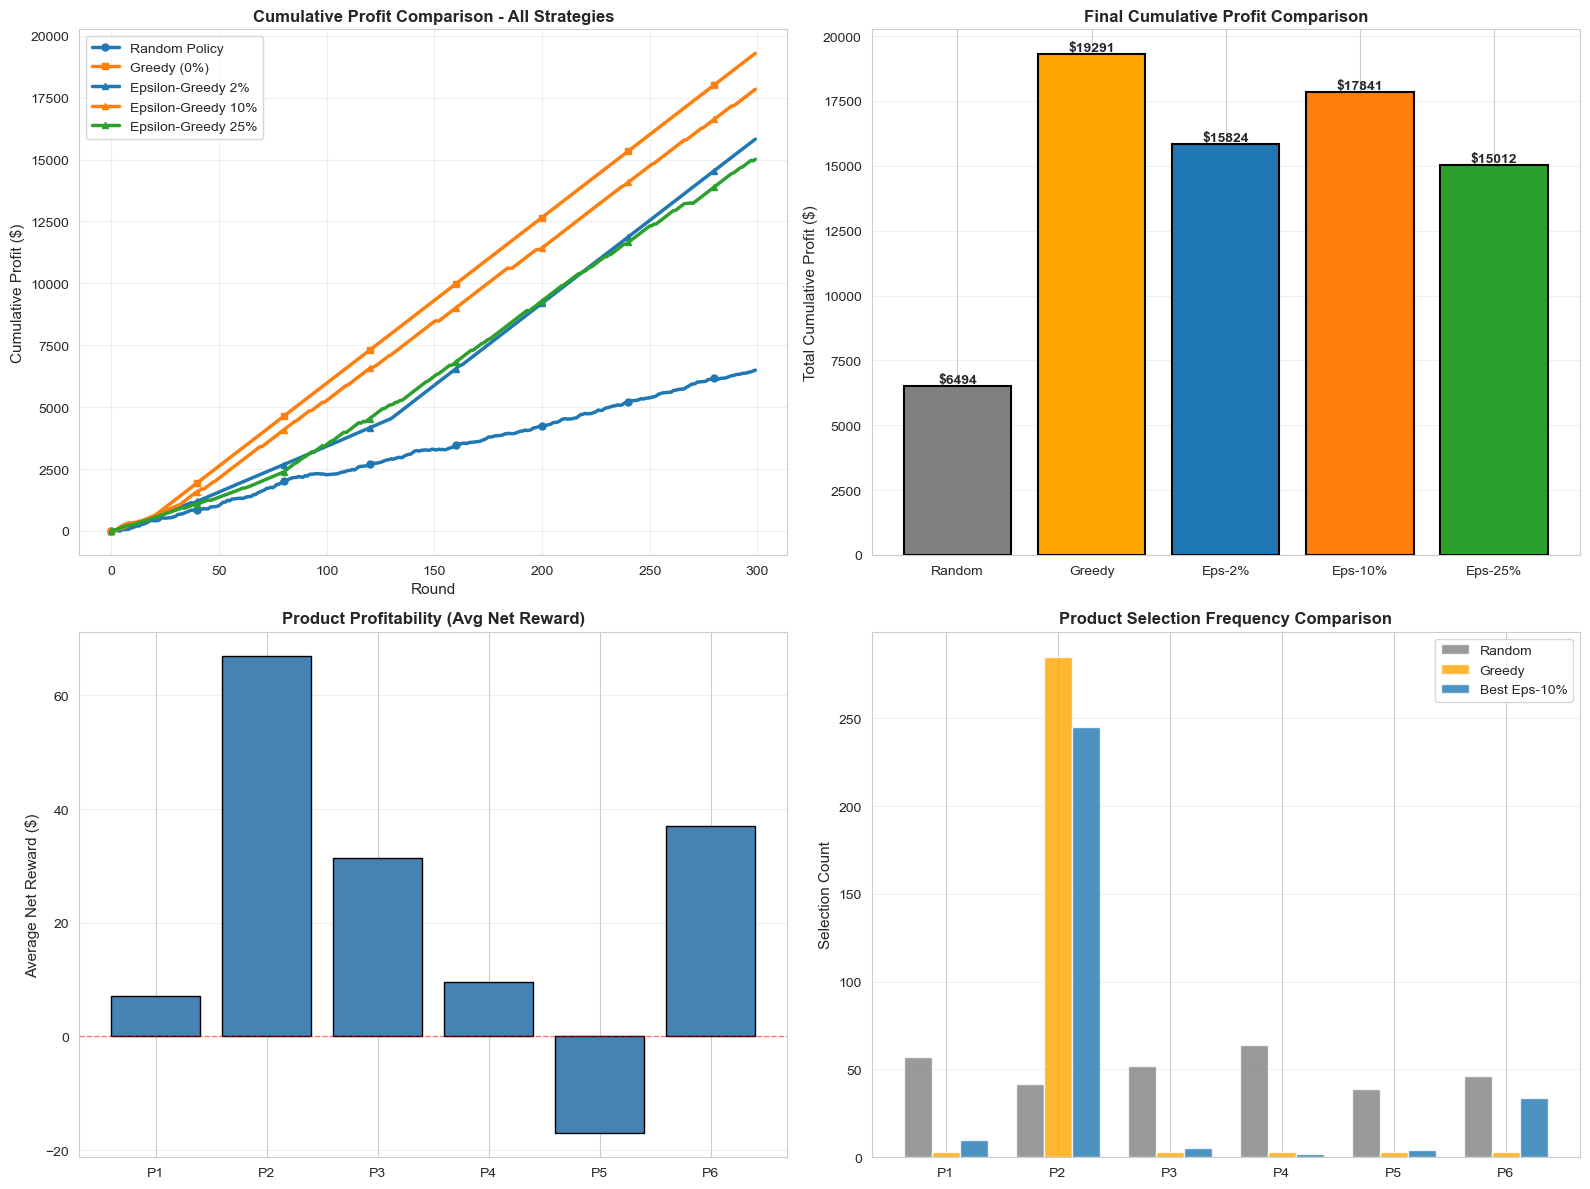


────────────────────────────────────────────────────────────────────────────────

✓ FINDINGS:

1. BEST OVERALL STRATEGY: Greedy with $19290.78 cumulative profit

2. PROFIT IMPROVEMENT:
   Greedy vs Random: +197.0%
   Epsilon-2% vs Random: +143.7%
   Epsilon-10% vs Random: +174.7%
   Epsilon-25% vs Random: +131.2%

3. MOST PROFITABLE PRODUCT: Product 2 (avg reward: $66.99)

4. LEAST PROFITABLE PRODUCT: Product 5 (avg reward: $-17.06)

────────────────────────────────────────────────────────────────────────────────



In [7]:
# Plot the cumulative net profit curves for all strategies tested.
# Which strategy produced the highest long-term cumulative profit, and why?
# Which product consistently emerged as the most profitable choice?

#-----write your code below this line---------

print("="*80)
print("STRATEGY COMPARISON & CUMULATIVE PROFIT ANALYSIS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: All strategies cumulative profit
ax = axes[0, 0]
ax.plot(cumulative_random, linewidth=2.5, label='Random Policy', marker='o', markevery=40, markersize=5)
ax.plot(cumulative_greedy, linewidth=2.5, label='Greedy (0%)', marker='s', markevery=40, markersize=5)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for epsilon, color in zip(epsilon_values, colors):
    result = epsilon_results[epsilon]
    ax.plot(result['cumulative'], linewidth=2.5, label=f'Epsilon-Greedy {epsilon:.0%}', 
            marker='^', markevery=40, markersize=5, color=color)

ax.set_xlabel('Round', fontsize=11)
ax.set_ylabel('Cumulative Profit ($)', fontsize=11)
ax.set_title('Cumulative Profit Comparison - All Strategies', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

# Plot 2: Final cumulative profit comparison (bar chart)
ax = axes[0, 1]
strategies = ['Random', 'Greedy'] + [f'Eps-{e:.0%}' for e in epsilon_values]
profits = [cumulative_random[-1], cumulative_greedy[-1]] + [epsilon_results[e]['total_profit'] for e in epsilon_values]
colors_bar = ['gray', 'orange'] + colors

bars = ax.bar(strategies, profits, color=colors_bar, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Total Cumulative Profit ($)', fontsize=11)
ax.set_title('Final Cumulative Profit Comparison', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar, profit in zip(bars, profits):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${profit:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: Product profitability (average net rewards)
ax = axes[1, 0]
product_means = [env.summary_df[env.summary_df['Product']==i]['Mean'].values[0] for i in range(1, 7)]
product_labels = [f'P{i}' for i in range(1, 7)]
bars = ax.bar(product_labels, product_means, color='steelblue', edgecolor='black')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel('Average Net Reward ($)', fontsize=11)
ax.set_title('Product Profitability (Avg Net Reward)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Product selection frequency across strategies
ax = axes[1, 1]
best_eg_counts = list(best_eg_result['counts'].values())
x = np.arange(len(product_labels))
width = 0.25

ax.bar(x - width, [random_products.count(i) for i in range(1, 7)], width, label='Random', color='gray', alpha=0.8)
ax.bar(x, [greedy_products.count(i) for i in range(1, 7)], width, label='Greedy', color='orange', alpha=0.8)
ax.bar(x + width, best_eg_counts, width, label=f'Best Eps-{best_epsilon:.0%}', color='#1f77b4', alpha=0.8)

ax.set_ylabel('Selection Count', fontsize=11)
ax.set_title('Product Selection Frequency Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(product_labels)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary findings
print(f"\n{'─'*80}")
print("\n✓ FINDINGS:\n")
print(f"1. BEST OVERALL STRATEGY: ", end="")
best_strategy = max([('Random', cumulative_random[-1]), ('Greedy', cumulative_greedy[-1])] + 
                     [(f'Epsilon {e:.0%}', epsilon_results[e]['total_profit']) for e in epsilon_values],
                     key=lambda x: x[1])
print(f"{best_strategy[0]} with ${best_strategy[1]:.2f} cumulative profit")

print(f"\n2. PROFIT IMPROVEMENT:")
random_improvement = ((cumulative_greedy[-1] - cumulative_random[-1]) / cumulative_random[-1]) * 100
print(f"   Greedy vs Random: {random_improvement:+.1f}%")

for epsilon in epsilon_values:
    eps_improvement = ((epsilon_results[epsilon]['total_profit'] - cumulative_random[-1]) / cumulative_random[-1]) * 100
    print(f"   Epsilon-{epsilon:.0%} vs Random: {eps_improvement:+.1f}%")

print(f"\n3. MOST PROFITABLE PRODUCT: Product {env.best_product} (avg reward: ${env.best_mean:.2f})")
print(f"\n4. LEAST PROFITABLE PRODUCT: Product {env.worst_product} (avg reward: ${env.worst_mean:.2f})")

print(f"\n{'─'*80}\n")